# QPU Benchmark Analysis – QFT, GHZ & QPE

Analyses results from `submit_QFT.py`, `submit_GHZ.py`, and `submit_QPE.py` runs across AWS QPU devices.

**Sections**
- **Section 0** – Imports and helper functions
- **Section 1** – Local simulator baseline (QFT, GHZ, and QPE, no noise)
- **Section 2** – Hardware results, per device:
  - 2-1 IonQ Forte-1
  - 2-2 IonQ Forte-Enterprise-1
  - 2-3 IQM Garnet
  - 2-4 AQT Ibex-Q1
  - 2-5 IQM Emerald
  - 2-6 Rigetti Cepheus-1-108Q
- **Section 3** – Cross-device comparison

**Metrics**
- *QFT*: Total Variation Distance (TVD) from ideal uniform output distribution
- *GHZ*: Within-δ fraction — fraction of shots whose Hamming distance to |00…0⟩ or |11…1⟩ is ≤ δ. Sim baseline uses δ=0; hardware sections use `GHZ_DELTA`.
- *QPE*: Peak accuracy — fraction of shots at the ideal phase-estimate bin (T gate, φ = 1/8)
- *Timing*: queue time, wall time, QPU execution time (if reported by device)

---
## Section 0 – Imports and Helper Functions

In [1]:
import json
import os
import glob
import math

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from braket.circuits import Circuit
from braket.devices import LocalSimulator

JOB_RESULTS_DIR = os.path.join(os.getcwd(), 'job_results')
LOG_FILE        = os.path.join(JOB_RESULTS_DIR, 'job_log.txt')

PLOTS_DIR = os.path.join(os.getcwd(), 'plots')
_PLOT_SUBDIRS = {'QFT': 'qft', 'GHZ': 'ghz', 'QPE': 'qpe_target1'}
for _d in _PLOT_SUBDIRS.values():
    os.makedirs(os.path.join(PLOTS_DIR, _d), exist_ok=True)

print('job_results dir:', JOB_RESULTS_DIR)
print('plots dir      :', PLOTS_DIR)

job_results dir: /Users/user/python/QUEN_QPUF/qpu_benchmark/job_results
plots dir      : /Users/user/python/QUEN_QPUF/qpu_benchmark/plots


In [2]:

# ── Circuit builders ──────────────────────────────────────────────────────────

def build_qft(n: int) -> Circuit:
    """n-qubit QFT (H, CPhaseShift, SWAP)."""
    circ = Circuit()
    for i in range(n):
        circ.h(i)
        for j in range(i + 1, n):
            circ.cphaseshift(j, i, np.pi / 2 ** (j - i))
    for i in range(n // 2):
        circ.swap(i, n - 1 - i)
    return circ


def build_ghz(n: int) -> Circuit:
    """n-qubit GHZ state: H on qubit 0, then CNOT chain."""
    circ = Circuit()
    circ.h(0)
    for i in range(n - 1):
        circ.cnot(i, i + 1)
    return circ


def build_qpe(n_counting: int, phase: float = 1 / 8) -> Circuit:
    """
    QPE for a diagonal phase-gate unitary with eigenvalue e^(2πi·phase).
    Default: T gate (phase = 1/8, eigenstate |1⟩).

    Layout:
      qubits 0 .. n_counting-1 : counting register
      qubit  n_counting         : target (initialized to |1⟩)

    Ideal measurement on counting register: round(2^n_counting * phase).
    Uses native CPhaseShift — suitable for LocalSimulator.
    QPU submission uses the CNOT+Rz decomposition in submit_QPE.py.
    """
    target = n_counting
    circ   = Circuit()
    circ.x(target)                          # prepare eigenstate |1⟩

    # Hadamards on counting register
    for k in range(n_counting):
        circ.h(k)

    # Controlled-U^(2^k) gates
    for k in range(n_counting):
        angle = (2 * np.pi * phase) * (2 ** k)
        circ.cphaseshift(k, target, angle)

    # Inverse QFT — rotations first, then bit-reversal
    for i in range(n_counting - 1, -1, -1):
        circ.h(i)
        for j in range(i - 1, -1, -1):
            circ.cphaseshift(i, j, -np.pi / 2 ** (i - j))

    for i in range(n_counting // 2):
        circ.swap(i, n_counting - 1 - i)

    return circ


# ── Metrics ───────────────────────────────────────────────────────────────────

def tvd_from_uniform(counts: dict) -> float:
    """
    Total Variation Distance of measured distribution from uniform.
    QFT on |0...0⟩ ideally produces uniform over all 2^n bitstrings.
    Lower is better (0 = perfect).
    """
    total    = sum(counts.values())
    n_states = 2 ** len(next(iter(counts))) if counts else 1
    p_ideal  = 1.0 / n_states
    tvd      = 0.5 * sum(abs(cnt / total - p_ideal) for cnt in counts.values())
    n_unobs  = n_states - len(counts)
    tvd     += 0.5 * n_unobs * p_ideal
    return tvd


def ghz_within_delta_fraction(counts: dict, n_qubits: int, delta: int = 0) -> float:
    """
    Fraction of shots within Hamming distance `delta` of |00...0⟩ or |11...1⟩.
    A bitstring is counted if min(num_ones, num_zeros) <= delta.
    delta=0 reproduces the strict |00...0⟩ + |11...1⟩ fraction.
    """
    total = sum(counts.values())
    if not total:
        return 0.0
    hits = 0
    for k, cnt in counts.items():
        ones = k.count('1')
        if min(ones, n_qubits - ones) <= delta:
            hits += cnt
    return hits / total


def qpe_peak_accuracy(counts: dict, n_counting: int, phase: float = 1 / 8) -> tuple[float, int]:
    """
    Fraction of shots at the ideal peak bin for QPE.
    ideal_bin = round(2^n_counting * phase).
    counts must be over the counting register only (first n_counting bits).
    Returns (peak_fraction, ideal_bin). Higher fraction = better (1.0 = perfect).
    """
    ideal_bin = round(2 ** n_counting * phase)
    ideal_str = format(ideal_bin, f'0{n_counting}b')
    total      = sum(counts.values())
    peak_shots = counts.get(ideal_str, 0)
    return (peak_shots / total if total else 0.0), ideal_bin


# ── Plotting helpers ──────────────────────────────────────────────────────────

def plot_histogram(counts: dict, title: str, top_k: int = 20, ax=None):
    """Bar chart of the top_k most frequent outcomes. X-axis shows integer values."""
    total  = sum(counts.values())
    top    = sorted(counts.items(), key=lambda x: -x[1])[:top_k]
    labels = [int(k, 2) for k, _ in top]   # bitstring → integer
    vals   = [v / total for _, v in top]

    if ax is None:
        fig, ax = plt.subplots(figsize=(max(8, len(labels) * 0.5), 4))

    ax.bar(range(len(labels)), vals, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, fontsize=8)
    ax.set_xlabel('Outcome (decimal)')
    ax.set_ylabel('Probability')
    ax.set_title(title)
    return ax


def print_timing(result: dict):
    """Print timing summary for a retrieved result."""
    q  = result.get('queue_time_seconds')
    w  = result.get('wall_time_seconds')
    qp = result.get('qpu_time_seconds')
    print(f"  Queue+exec time : {q:.1f} s"  if q  is not None else "  Queue+exec time : N/A")
    print(f"  Wall time       : {w:.1f} s"  if w  is not None else "  Wall time       : N/A")
    print(f"  QPU exec time   : {qp:.4f} s" if qp is not None else "  QPU exec time   : not reported")


# ── Result loader ─────────────────────────────────────────────────────────────

def load_results(device_name: str | None = None,
                 circuit_type: str | None = None) -> list[dict]:
    """
    Load retrieved result JSONs from job_results/, with optional filters.
    Records without measurement counts (e.g. FAILED jobs that only contain
    metadata) are skipped — they have no analysable result.
    For duplicate (device, circuit_type, n_qubits) entries, only the most
    recent job (by submitted_at) is kept.
    """
    results = []
    for path in sorted(glob.glob(os.path.join(JOB_RESULTS_DIR, '*.json'))):
        with open(path) as f:
            rec = json.load(f)
        if 'circuit_type' not in rec:
            continue
        if 'counts' not in rec:
            continue
        if device_name  and rec.get('device')       != device_name:
            continue
        if circuit_type and rec.get('circuit_type') != circuit_type:
            continue
        results.append(rec)

    # Keep only the most recent result per (device, circuit_type, n_qubits)
    latest = {}
    for r in results:
        key = (r.get('device'), r.get('circuit_type'), r.get('n_qubits'))
        if key not in latest or r.get('submitted_at', '') > latest[key].get('submitted_at', ''):
            latest[key] = r
    return list(latest.values())


print('Helpers loaded.')


Helpers loaded.


---
## Section 1 – Local Simulator Baseline

Runs QFT, GHZ, and QPE circuits on the Braket `LocalSimulator` (no noise).  
These are the ideal reference results.

**Ideal outputs**
- QFT applied to |0...0⟩ → uniform distribution over all 2ⁿ bitstrings  
- GHZ state → 50 % |00...0⟩ and 50 % |11...1⟩
- QPE (T gate, φ = 1/8) → all shots at counting-register bin round(2^n_counting / 8)

In [3]:
SIM_N_QUBITS = 6    # qubit count for local sim demo
SIM_SHOTS    = 2000  # shots for local sim

simulator = LocalSimulator()
print(f'LocalSimulator ready. n_qubits={SIM_N_QUBITS}, shots={SIM_SHOTS}')

LocalSimulator ready. n_qubits=6, shots=2000


### 1-1: QFT – Circuit Display and Local Simulation

In [4]:
qft_circ = build_qft(SIM_N_QUBITS)
print(f'QFT circuit  n={SIM_N_QUBITS}  depth={qft_circ.depth}  gates={len(qft_circ.instructions)}')
print()
print(qft_circ.diagram())

QFT circuit  n=6  depth=12  gates=24

T  : │  0  │       1       │          2          │               3               │                  4                  │                       5                       │                  6                  │               7               │          8          │       9       │   10   │   11   │
      ┌───┐ ┌─────────────┐ ┌─────────────┐       ┌─────────────┐                 ┌─────────────┐                       ┌─────────────┐                                                                                                                                                               
q0 : ─┤ H ├─┤ PHASE(1.57) ├─┤ PHASE(0.79) ├───────┤ PHASE(0.39) ├─────────────────┤ PHASE(0.20) ├───────────────────────┤ PHASE(0.10) ├─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────x─────
      └───┘ └──────┬──────┘ └──────┬──────┘       └──────┬──────┘            

In [5]:
qft_task   = simulator.run(qft_circ, shots=SIM_SHOTS)
qft_result = qft_task.result()
qft_counts = dict(qft_result.measurement_counts)

qft_tvd = tvd_from_uniform(qft_counts)

print(f'QFT local simulation  (n={SIM_N_QUBITS}, shots={SIM_SHOTS})')
print(f'  Unique outcomes : {len(qft_counts)}')
print(f'  TVD from uniform: {qft_tvd:.4f}  (0 = ideal uniform)')
print(f'  Top 5 outcomes  :')
for k, v in sorted(qft_counts.items(), key=lambda x: -x[1])[:5]:
    print(f'    {k}  →  {v} shots  ({v/SIM_SHOTS:.3f})')

QFT local simulation  (n=6, shots=2000)
  Unique outcomes : 64
  TVD from uniform: 0.0695  (0 = ideal uniform)
  Top 5 outcomes  :
    110110  →  45 shots  (0.022)
    000011  →  44 shots  (0.022)
    011010  →  42 shots  (0.021)
    011111  →  40 shots  (0.020)
    010001  →  40 shots  (0.020)


Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qft/qft_sim_n6.png


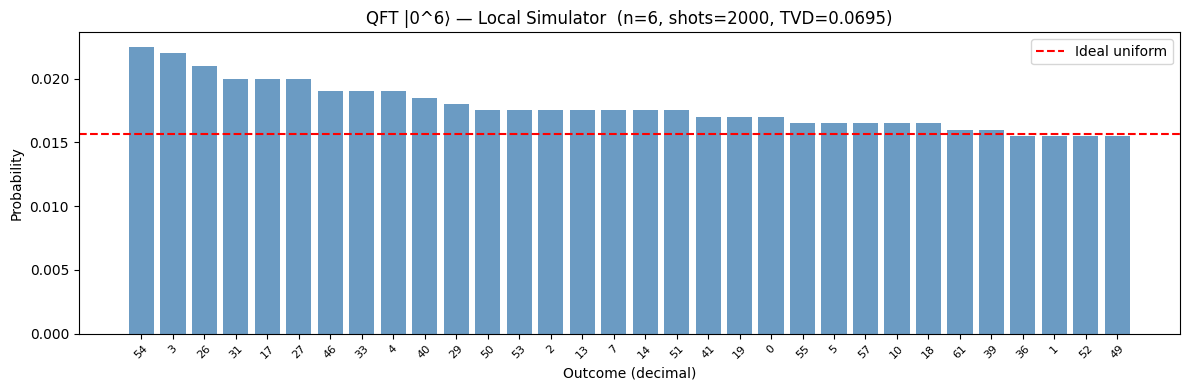

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_histogram(qft_counts,
               title=f'QFT |0^{SIM_N_QUBITS}⟩ — Local Simulator  '
                     f'(n={SIM_N_QUBITS}, shots={SIM_SHOTS}, TVD={qft_tvd:.4f})',
               top_k=32, ax=ax)
ax.axhline(1 / 2**SIM_N_QUBITS, color='red', linestyle='--', label='Ideal uniform')
ax.legend()
plt.tight_layout()
_path = os.path.join(PLOTS_DIR, 'qft', f'qft_sim_n{SIM_N_QUBITS}.png')
plt.savefig(_path, dpi=150)
print(f'Saved → {_path}')
plt.show()

### 1-2: GHZ – Circuit Display and Local Simulation

In [7]:
ghz_circ = build_ghz(SIM_N_QUBITS)
print(f'GHZ circuit  n={SIM_N_QUBITS}  depth={ghz_circ.depth}  gates={len(ghz_circ.instructions)}')
print()
print(ghz_circ.diagram())

GHZ circuit  n=6  depth=6  gates=6

T  : │  0  │  1  │  2  │  3  │  4  │  5  │
      ┌───┐                               
q0 : ─┤ H ├───●───────────────────────────
      └───┘   │                           
            ┌─┴─┐                         
q1 : ───────┤ X ├───●─────────────────────
            └───┘   │                     
                  ┌─┴─┐                   
q2 : ─────────────┤ X ├───●───────────────
                  └───┘   │               
                        ┌─┴─┐             
q3 : ───────────────────┤ X ├───●─────────
                        └───┘   │         
                              ┌─┴─┐       
q4 : ─────────────────────────┤ X ├───●───
                              └───┘   │   
                                    ┌─┴─┐ 
q5 : ───────────────────────────────┤ X ├─
                                    └───┘ 
T  : │  0  │  1  │  2  │  3  │  4  │  5  │


In [8]:
ghz_task   = simulator.run(ghz_circ, shots=SIM_SHOTS)
ghz_result = ghz_task.result()
ghz_counts = dict(ghz_result.measurement_counts)

ghz_frac = ghz_within_delta_fraction(ghz_counts, SIM_N_QUBITS, delta=0)

print(f'GHZ local simulation  (n={SIM_N_QUBITS}, shots={SIM_SHOTS})')
print(f'  Unique outcomes   : {len(ghz_counts)}')
print(f'  Ideal fraction    : {ghz_frac:.4f}  (1.0 = perfect GHZ, δ=0)')
print(f'  All outcomes      :')
for k, v in sorted(ghz_counts.items(), key=lambda x: -x[1]):
    label = '  ← ideal' if k in {'0'*SIM_N_QUBITS, '1'*SIM_N_QUBITS} else ''
    print(f'    {k}  →  {v} shots  ({v/SIM_SHOTS:.3f}){label}')

GHZ local simulation  (n=6, shots=2000)
  Unique outcomes   : 2
  Ideal fraction    : 1.0000  (1.0 = perfect GHZ, δ=0)
  All outcomes      :
    000000  →  1007 shots  (0.503)  ← ideal
    111111  →  993 shots  (0.496)  ← ideal


Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/ghz_sim_n6.png


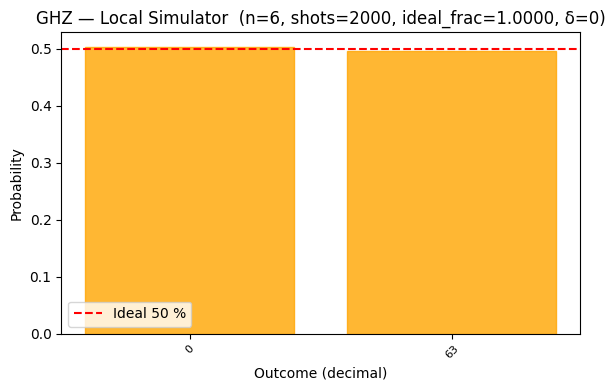

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
plot_histogram(ghz_counts,
               title=f'GHZ — Local Simulator  '
                     f'(n={SIM_N_QUBITS}, shots={SIM_SHOTS}, ideal_frac={ghz_frac:.4f}, δ=0)',
               top_k=len(ghz_counts), ax=ax)
keys = sorted(ghz_counts.items(), key=lambda x: -x[1])
ideal_set = {'0'*SIM_N_QUBITS, '1'*SIM_N_QUBITS}
for idx, (k, _) in enumerate(keys):
    if k in ideal_set:
        ax.get_children()[idx].set_color('orange')
ax.axhline(0.5, color='red', linestyle='--', label='Ideal 50 %')
ax.legend()
plt.tight_layout()
_path = os.path.join(PLOTS_DIR, 'ghz', f'ghz_sim_n{SIM_N_QUBITS}.png')
plt.savefig(_path, dpi=150)
print(f'Saved → {_path}')
plt.show()

### 1-3: QPE – Circuit Display and Local Simulation

In [10]:
QPE_N_COUNTING = 5    # counting qubits; total qubits = QPE_N_COUNTING + 1

qpe_circ = build_qpe(QPE_N_COUNTING)
print(f'QPE circuit  n_counting={QPE_N_COUNTING}  n_total={QPE_N_COUNTING + 1}  '
      f'depth={qpe_circ.depth}  gates={len(qpe_circ.instructions)}')
print(f'Unitary : T gate  |  Phase φ = 1/8  |  Ideal peak bin = {round(2**QPE_N_COUNTING / 8)}')
print()
print(qpe_circ.diagram())

QPE circuit  n_counting=5  n_total=6  depth=16  gates=28
Unitary : T gate  |  Phase φ = 1/8  |  Ideal peak bin = 4

T  : │  0  │       1       │       2       │       3       │       4       │       5        │  6  │       7        │          8           │                9                │                  10                   │               11                │          12          │       13       │   14   │   15   │
      ┌───┐                                                                                                                                                                  ┌──────────────┐                        ┌──────────────┐                  ┌──────────────┐       ┌──────────────┐  ┌───┐            
q0 : ─┤ H ├────────●─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤ PHASE(-0.20) ├────────────────────────┤ PHASE(-0.39) ├──────────────────┤ PHASE(-0.79) ├───────┤ 

In [11]:
qpe_task       = simulator.run(qpe_circ, shots=SIM_SHOTS)
qpe_result     = qpe_task.result()
qpe_counts_all = dict(qpe_result.measurement_counts)

# Marginalise over target qubit (last bit) → counting-register distribution
qpe_counts = {}
for bitstr, cnt in qpe_counts_all.items():
    key = bitstr[:QPE_N_COUNTING]
    qpe_counts[key] = qpe_counts.get(key, 0) + cnt

qpe_peak_frac, qpe_ideal_bin = qpe_peak_accuracy(qpe_counts, QPE_N_COUNTING)

print(f'QPE local simulation  (n_counting={QPE_N_COUNTING}, n_total={QPE_N_COUNTING + 1}, shots={SIM_SHOTS})')
print(f'  Ideal peak bin   : {qpe_ideal_bin}  '
      f'(binary {format(qpe_ideal_bin, f"0{QPE_N_COUNTING}b")})  →  '
      f'φ ≈ {qpe_ideal_bin / 2**QPE_N_COUNTING:.4f}')
print(f'  Peak accuracy    : {qpe_peak_frac:.4f}  (1.0 = all shots at ideal bin)')
print(f'  Top 5 outcomes (counting register):')
for k, v in sorted(qpe_counts.items(), key=lambda x: -x[1])[:5]:
    marker = '  ← ideal' if int(k, 2) == qpe_ideal_bin else ''
    print(f'    {k}  ({int(k, 2):3d})  →  {v} shots  ({v / SIM_SHOTS:.3f}){marker}')

QPE local simulation  (n_counting=5, n_total=6, shots=2000)
  Ideal peak bin   : 4  (binary 00100)  →  φ ≈ 0.1250
  Peak accuracy    : 1.0000  (1.0 = all shots at ideal bin)
  Top 5 outcomes (counting register):
    00100  (  4)  →  2000 shots  (1.000)  ← ideal


Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/qpe_sim_n5.png


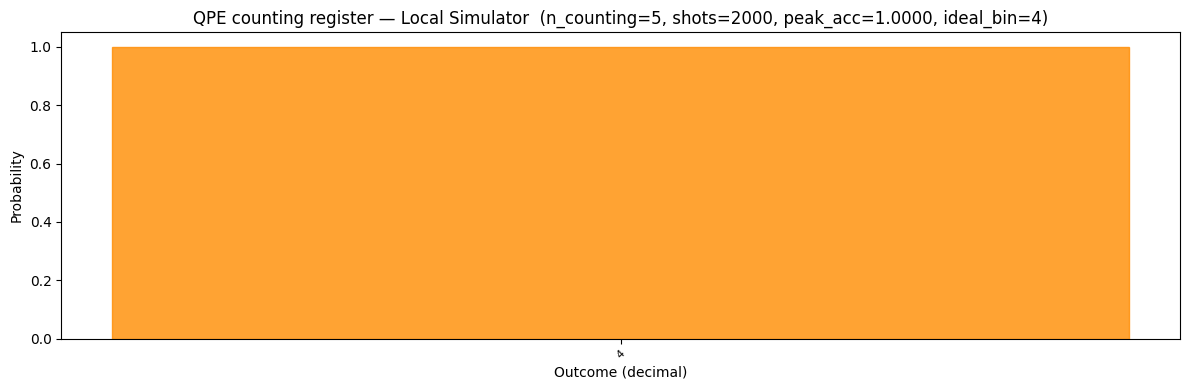

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
plot_histogram(qpe_counts,
               title=(f'QPE counting register — Local Simulator  '
                      f'(n_counting={QPE_N_COUNTING}, shots={SIM_SHOTS}, '
                      f'peak_acc={qpe_peak_frac:.4f}, ideal_bin={qpe_ideal_bin})'),
               top_k=2 ** QPE_N_COUNTING, ax=ax)
top_items = sorted(qpe_counts.items(), key=lambda x: -x[1])[:2 ** QPE_N_COUNTING]
top_ints  = [int(k, 2) for k, _ in top_items]
if qpe_ideal_bin in top_ints:
    ax.get_children()[top_ints.index(qpe_ideal_bin)].set_color('darkorange')
plt.tight_layout()
_path = os.path.join(PLOTS_DIR, 'qpe_target1', f'qpe_sim_n{QPE_N_COUNTING}.png')
plt.savefig(_path, dpi=150)
print(f'Saved → {_path}')
plt.show()

---
## Section 2 – Hardware Results

Run `checkRetieve.py` on the DCV first to populate `job_results/*.json`.  
Each sub-section loads results for one QPU device.

For each device two jobs are expected per circuit type:
- **half**: n = max_qubits // 2
- **full**: n = max_qubits

For QPE jobs: `n_qubits` = n_counting + 1 (1 target qubit). Counting register is the first n_counting bits of the measurement bitstring.

| # | Device | Company | Qubits | Notes |
|---|--------|---------|--------|-------|
| 2-1 | Forte-1 | IonQ | 36 | trapped-ion |
| 2-2 | Forte-Enterprise-1 | IonQ | 36 | trapped-ion |
| 2-3 | Garnet | IQM | 20 | superconducting |
| 2-4 | Ibex-Q1 | AQT | 12 | trapped-ion, eu-north-1 |
| 2-5 | Emerald | IQM | TBD | superconducting, eu-north-1 |
| 2-6 | Cepheus-1-108Q | Rigetti | 108 | superconducting |

In [13]:
# Hamming-distance tolerance for GHZ within-δ fraction (hardware sections only).
# delta=0 reproduces the strict |00...0⟩ + |11...1⟩ fraction.
GHZ_DELTA = 2

# Load all available hardware results
all_results = load_results()

if not all_results:
    print('No hardware results found yet in', JOB_RESULTS_DIR)
    print('Run checkRetrieve.py on the DCV first.')
else:
    print(f'Loaded {len(all_results)} hardware result(s)  (GHZ_DELTA={GHZ_DELTA}):')
    print(f'  {"Device":24s}  {"Circuit":6s}  {"Qubits":6s}  {"Shots":6s}  {"Status"}')
    print(f'  {"-"*65}')
    for r in all_results:
        uuid = r['task_id'].split('/')[-1][:8]
        print(f'  {r["device"]:24s}  {r["circuit_type"]:6s}  '
              f'{r["n_qubits"]:6d}  {r["n_shots_actual"]:6d}  {uuid}...')

Loaded 22 hardware result(s)  (GHZ_DELTA=2):
  Device                    Circuit  Qubits  Shots   Status
  -----------------------------------------------------------------
  Emerald                   QPE         27     256  03511793...
  Garnet                    GHZ         20     256  1e02ea19...
  Garnet                    QFT         20     256  3c100d9b...
  Forte-Enterprise-1        GHZ         18     256  55b99581...
  Emerald                   QPE          5     256  68a1b0fe...
  Forte-Enterprise-1        GHZ         36     256  6a7e2d20...
  Cepheus-1-108Q            QPE         10     256  6f87f576...
  Emerald                   QPE         20     256  6fed6cea...
  Forte-Enterprise-1        QPE         18     256  7146c5e3...
  Forte-Enterprise-1        QPE         36     256  74bd7a39...
  Ibex-Q1                   QPE          6     256  a998da02...
  Garnet                    QPE         20     256  7e72b746...
  Garnet                    QFT         10     256  834addd

### Per-device analysis helper

In [14]:
def analyse_device(device_name: str):
    """
    Load and display all results for a given device.
    Shows histograms, metrics, and timing for each (circuit_type, n_qubits) pair.
    Handles QFT, GHZ, and QPE circuit types. Saves each plot to plots/<type>/.
    GHZ uses the within-δ fraction with δ = GHZ_DELTA.
    """
    results = load_results(device_name=device_name)
    if not results:
        print(f'  No results found for {device_name}.')
        return

    print(f'\n{"="*70}')
    print(f'  Device : {device_name}  ({len(results)} result(s), GHZ_DELTA={GHZ_DELTA})')

    results.sort(key=lambda r: (r['circuit_type'], r['n_qubits']))

    for r in results:
        ctype  = r['circuit_type']
        n      = r['n_qubits']
        shots  = r['n_shots_actual']
        counts = r['counts']
        uuid   = r['task_id'].split('/')[-1]

        print(f'\n  [{ctype}  n={n}]  shots={shots}  task={uuid[:8]}...')

        # ── Metric ────────────────────────────────────────────────────────────
        if ctype == 'QFT':
            tvd = tvd_from_uniform(counts)
            print(f'    TVD from uniform : {tvd:.4f}  (lower = closer to ideal)')

        elif ctype == 'GHZ':
            frac        = ghz_within_delta_fraction(counts, n, delta=GHZ_DELTA)
            frac_strict = ghz_within_delta_fraction(counts, n, delta=0)
            print(f'    GHZ frac (δ={GHZ_DELTA}) : {frac:.4f}  '
                  f'(strict δ=0: {frac_strict:.4f}, 1.0 = perfect)')
            if 'ghz_verification' in r:
                v = r['ghz_verification']
                print(f'    Ideal shots      : {v["ideal_shots"]}/{v["total_shots"]}')

        elif ctype == 'QPE':
            n_counting = r.get('n_counting', n - 1)
            counts_reg = {}
            for bitstr, cnt in counts.items():
                key = bitstr[:n_counting]
                counts_reg[key] = counts_reg.get(key, 0) + cnt
            peak_frac, ideal_bin = qpe_peak_accuracy(counts_reg, n_counting)
            print(f'    QPE peak accuracy: {peak_frac:.4f}  (1.0 = all shots at ideal bin)')
            print(f'    Ideal bin        : {ideal_bin}  '
                  f'(binary {format(ideal_bin, f"0{n_counting}b")})  →  φ ≈ {ideal_bin / 2**n_counting:.4f}')
            counts = counts_reg

        # ── Timing ────────────────────────────────────────────────────────────
        print_timing(r)

        # ── Histogram ─────────────────────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(12, 3))
        plot_histogram(
            counts,
            title=f'{device_name}  [{ctype}  n={n}]  shots={shots}',
            top_k=20,
            ax=ax,
        )
        if ctype == 'QFT':
            ax.axhline(1 / 2**n, color='red', linestyle='--', label='Ideal uniform')
            ax.legend()
        elif ctype == 'GHZ':
            ax.set_title(ax.get_title() +
                         f'  |  frac(δ={GHZ_DELTA})={ghz_within_delta_fraction(counts, n, delta=GHZ_DELTA):.4f}')
        elif ctype == 'QPE':
            n_counting = r.get('n_counting', n - 1)
            peak_frac, ideal_bin = qpe_peak_accuracy(counts, n_counting)
            ax.set_title(ax.get_title() + f'  |  peak_acc={peak_frac:.4f}  ideal_bin={ideal_bin}')
            top_items = sorted(counts.items(), key=lambda x: -x[1])[:20]
            top_ints  = [int(k, 2) for k, _ in top_items]
            if ideal_bin in top_ints:
                ax.get_children()[top_ints.index(ideal_bin)].set_color('darkorange')

        plt.tight_layout()
        _subdir  = _PLOT_SUBDIRS.get(ctype, ctype.lower())
        _devname = device_name.replace('-', '_').replace(' ', '_')
        _path    = os.path.join(PLOTS_DIR, _subdir, f'{_devname}_{ctype.lower()}_n{n}.png')
        plt.savefig(_path, dpi=150)
        print(f'    Saved → {_path}')
        plt.show()


print('analyse_device() ready.')

analyse_device() ready.


---
### 2-1: IonQ Forte-1


  Device : Forte-1  (2 result(s), GHZ_DELTA=2)

  [QPE  n=18]  shots=256  task=a4caf4d2...
    QPE peak accuracy: 0.0000  (1.0 = all shots at ideal bin)
    Ideal bin        : 16384  (binary 00100000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 12294.1 s
  Wall time       : 12295.5 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Forte_1_qpe_n18.png


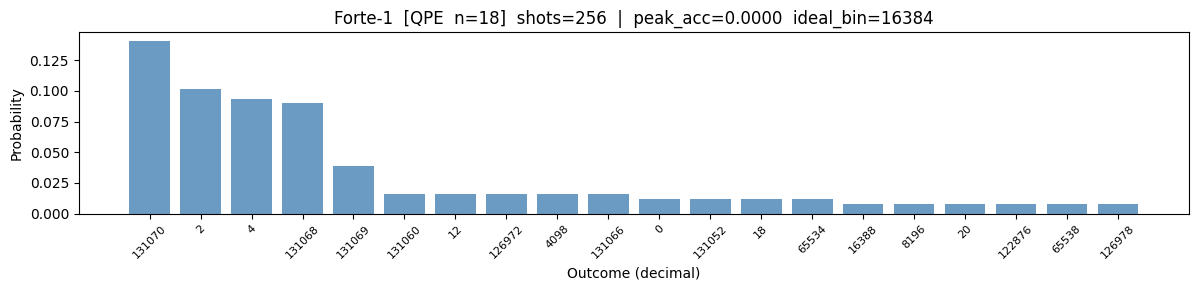


  [QPE  n=36]  shots=256  task=cfacffe6...
    QPE peak accuracy: 0.0000  (1.0 = all shots at ideal bin)
    Ideal bin        : 4294967296  (binary 00100000000000000000000000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 12367.4 s
  Wall time       : 12368.0 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Forte_1_qpe_n36.png


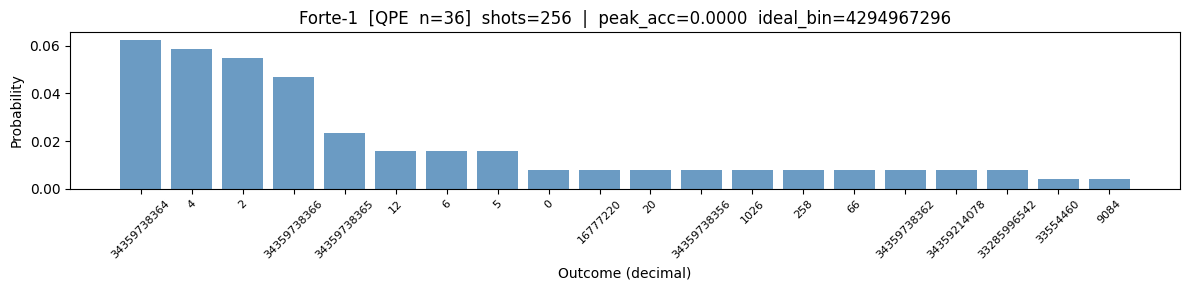

In [15]:
analyse_device('Forte-1')

---
### 2-2: IonQ Forte-Enterprise-1


  Device : Forte-Enterprise-1  (5 result(s), GHZ_DELTA=2)

  [GHZ  n=18]  shots=256  task=55b99581...
    GHZ frac (δ=2) : 0.9453  (strict δ=0: 0.7109, 1.0 = perfect)
    Ideal shots      : 182/256
  Queue+exec time : 1561.9 s
  Wall time       : 1562.8 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/Forte_Enterprise_1_ghz_n18.png


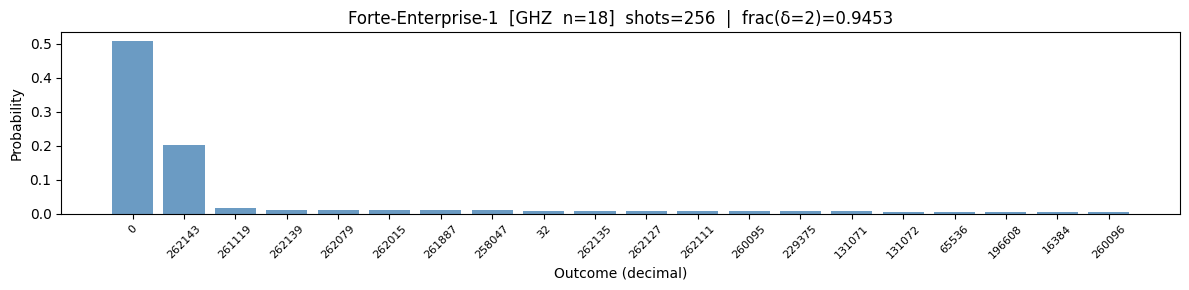


  [GHZ  n=36]  shots=256  task=6a7e2d20...
    GHZ frac (δ=2) : 0.7773  (strict δ=0: 0.4648, 1.0 = perfect)
    Ideal shots      : 119/256
  Queue+exec time : 1753.7 s
  Wall time       : 1753.9 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/Forte_Enterprise_1_ghz_n36.png


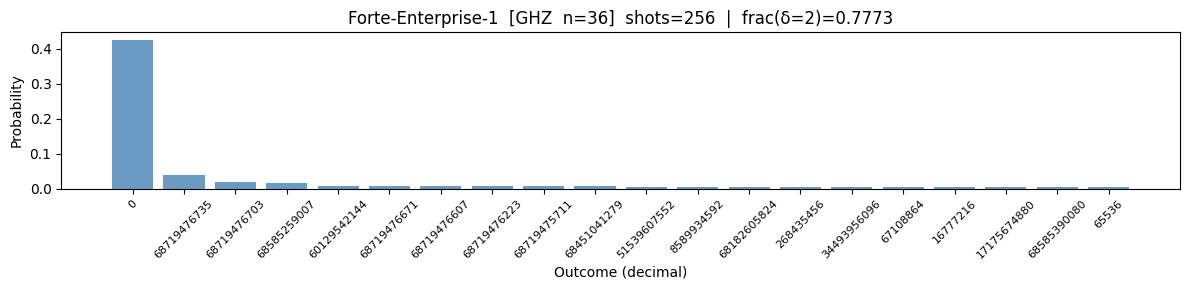


  [QPE  n=10]  shots=256  task=cf956ad6...
    QPE peak accuracy: 0.0000  (1.0 = all shots at ideal bin)
    Ideal bin        : 64  (binary 001000000)  →  φ ≈ 0.1250
  Queue+exec time : 360.2 s
  Wall time       : 362.1 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Forte_Enterprise_1_qpe_n10.png


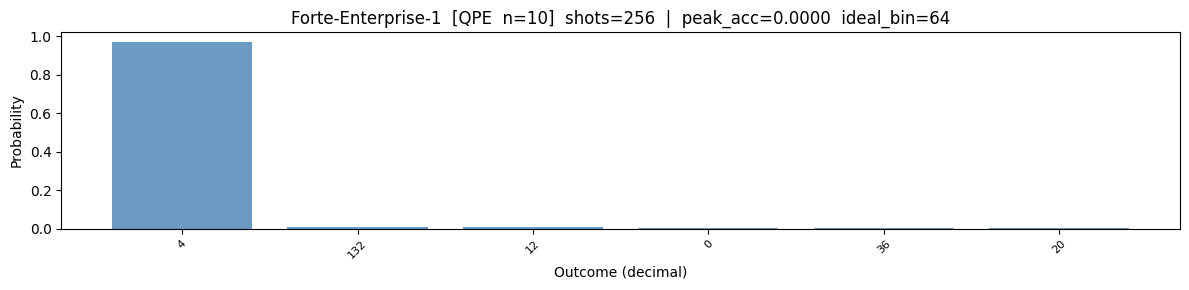


  [QPE  n=18]  shots=256  task=7146c5e3...
    QPE peak accuracy: 0.8516  (1.0 = all shots at ideal bin)
    Ideal bin        : 16384  (binary 00100000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 1659.5 s
  Wall time       : 1660.9 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Forte_Enterprise_1_qpe_n18.png


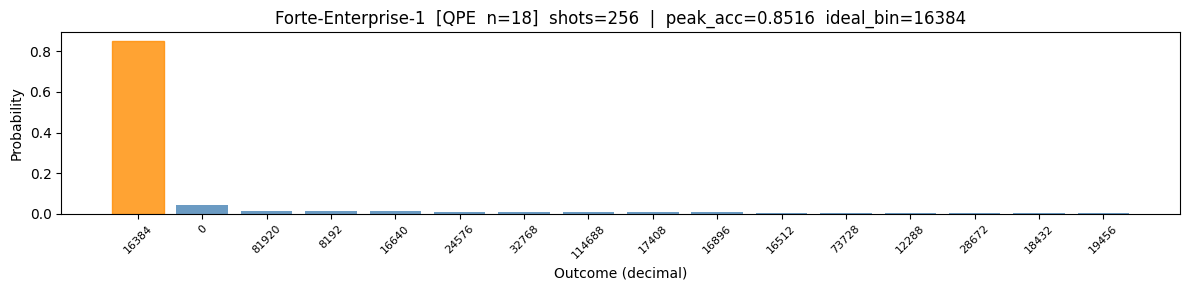


  [QPE  n=36]  shots=256  task=74bd7a39...
    QPE peak accuracy: 0.3398  (1.0 = all shots at ideal bin)
    Ideal bin        : 4294967296  (binary 00100000000000000000000000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 1016.1 s
  Wall time       : 1016.8 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Forte_Enterprise_1_qpe_n36.png


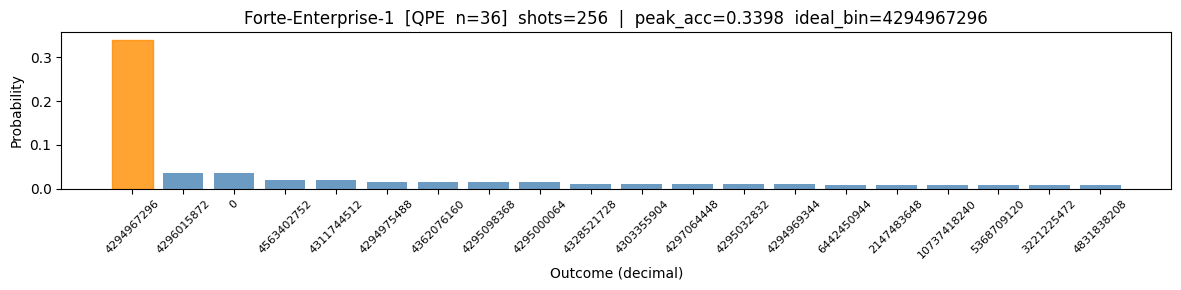

In [16]:
analyse_device('Forte-Enterprise-1')

---
### 2-3: IQM Garnet


  Device : Garnet  (6 result(s), GHZ_DELTA=2)

  [GHZ  n=10]  shots=256  task=c07009c0...
    GHZ frac (δ=2) : 0.8164  (strict δ=0: 0.5312, 1.0 = perfect)
    Ideal shots      : 136/256
  Queue+exec time : 3.4 s
  Wall time       : 4.7 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/Garnet_ghz_n10.png


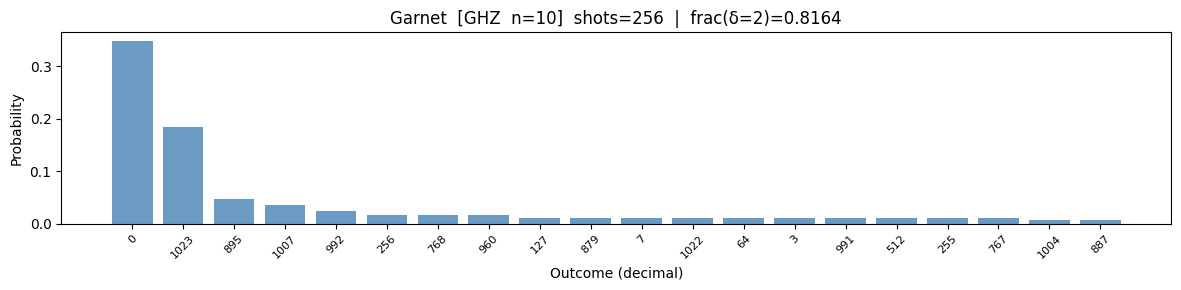


  [GHZ  n=20]  shots=256  task=1e02ea19...
    GHZ frac (δ=2) : 0.3828  (strict δ=0: 0.0742, 1.0 = perfect)
    Ideal shots      : 19/256
  Queue+exec time : 7.6 s
  Wall time       : 7.9 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/Garnet_ghz_n20.png


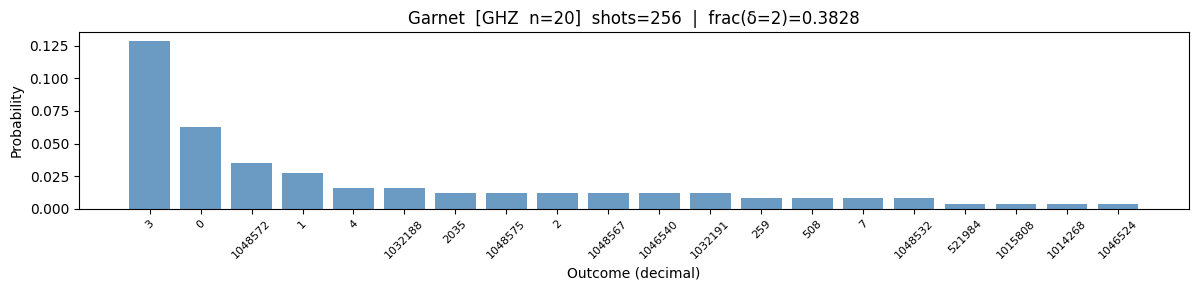


  [QFT  n=10]  shots=256  task=834addd9...
    TVD from uniform : 0.7871  (lower = closer to ideal)
  Queue+exec time : 8.1 s
  Wall time       : 9.9 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qft/Garnet_qft_n10.png


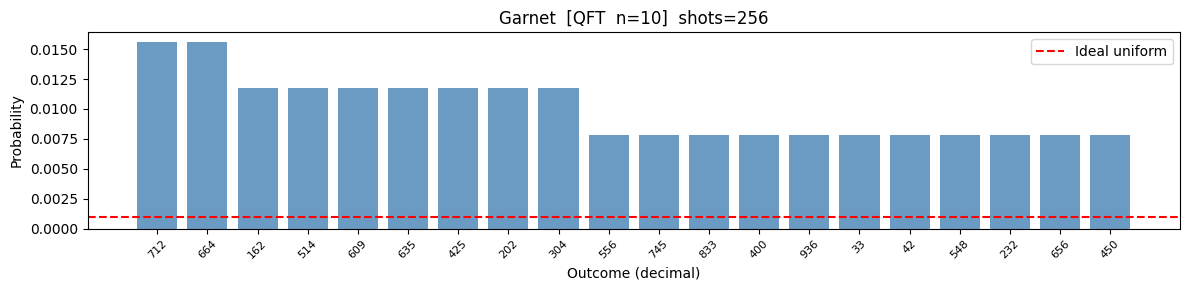


  [QFT  n=20]  shots=256  task=3c100d9b...
    TVD from uniform : 0.9998  (lower = closer to ideal)
  Queue+exec time : 13.9 s
  Wall time       : 14.2 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qft/Garnet_qft_n20.png


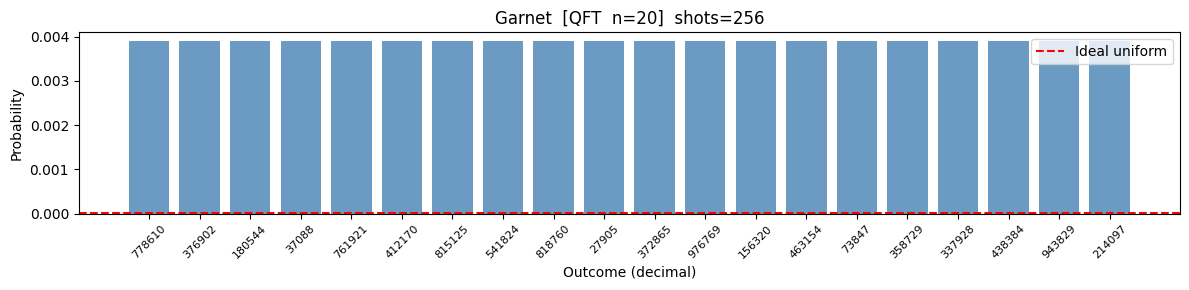


  [QPE  n=10]  shots=256  task=f81b9537...
    QPE peak accuracy: 0.0117  (1.0 = all shots at ideal bin)
    Ideal bin        : 64  (binary 001000000)  →  φ ≈ 0.1250
  Queue+exec time : 8.1 s
  Wall time       : 9.1 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Garnet_qpe_n10.png


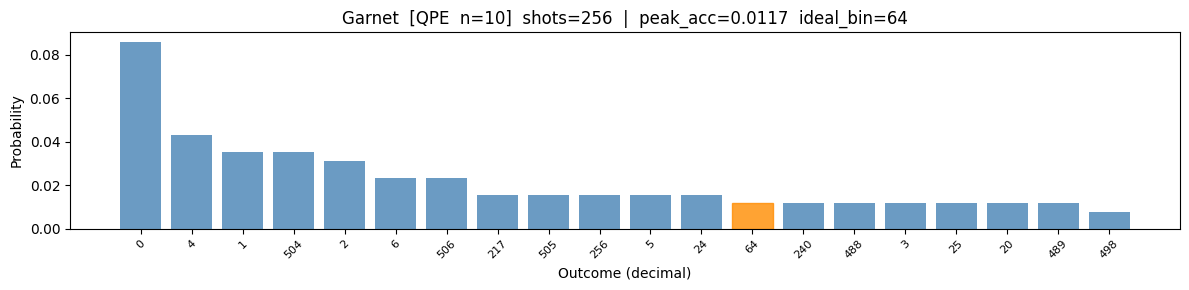


  [QPE  n=20]  shots=256  task=7e72b746...
    QPE peak accuracy: 0.0039  (1.0 = all shots at ideal bin)
    Ideal bin        : 65536  (binary 0010000000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 13.7 s
  Wall time       : 15.4 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Garnet_qpe_n20.png


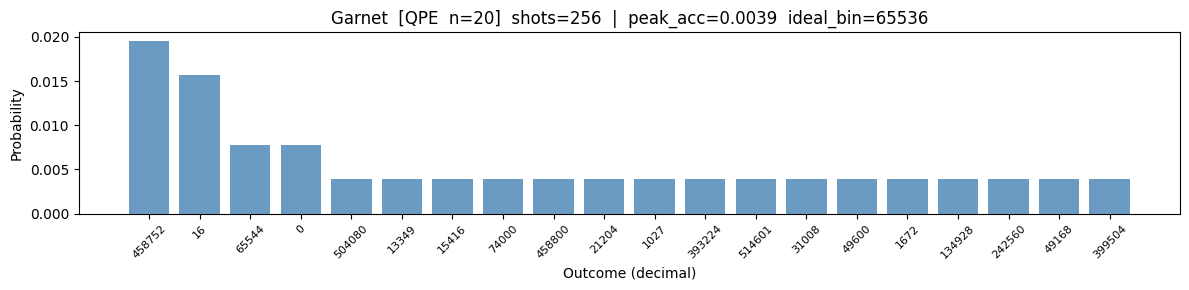

In [17]:
analyse_device('Garnet')

---
### 2-4: AQT Ibex-Q1


  Device : Ibex-Q1  (2 result(s), GHZ_DELTA=2)

  [QPE  n=6]  shots=256  task=a998da02...
    QPE peak accuracy: 0.2227  (1.0 = all shots at ideal bin)
    Ideal bin        : 4  (binary 00100)  →  φ ≈ 0.1250
  Queue+exec time : 762.4 s
  Wall time       : 764.0 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Ibex_Q1_qpe_n6.png


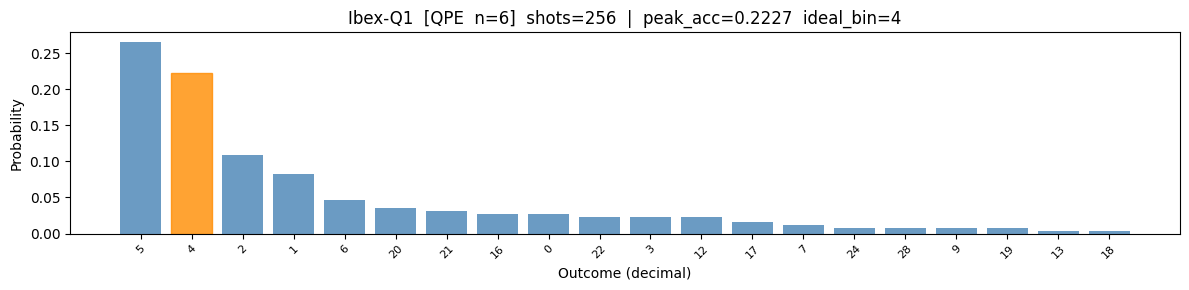


  [QPE  n=12]  shots=256  task=d537a704...
    QPE peak accuracy: 0.0000  (1.0 = all shots at ideal bin)
    Ideal bin        : 256  (binary 00100000000)  →  φ ≈ 0.1250
  Queue+exec time : 67.9 s
  Wall time       : 69.4 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Ibex_Q1_qpe_n12.png


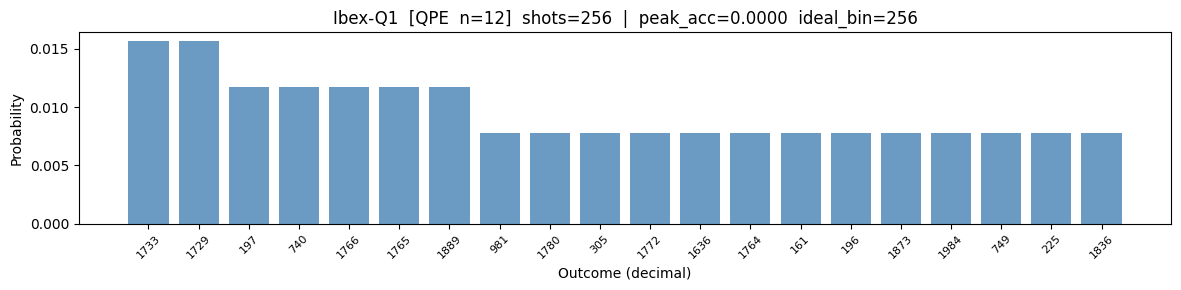

In [18]:
analyse_device('Ibex-Q1')

---
### 2-5: IQM Emerald


  Device : Emerald  (4 result(s), GHZ_DELTA=2)

  [QPE  n=5]  shots=256  task=68a1b0fe...
    QPE peak accuracy: 0.8320  (1.0 = all shots at ideal bin)
    Ideal bin        : 2  (binary 0010)  →  φ ≈ 0.1250
  Queue+exec time : 9.2 s
  Wall time       : 11.1 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Emerald_qpe_n5.png


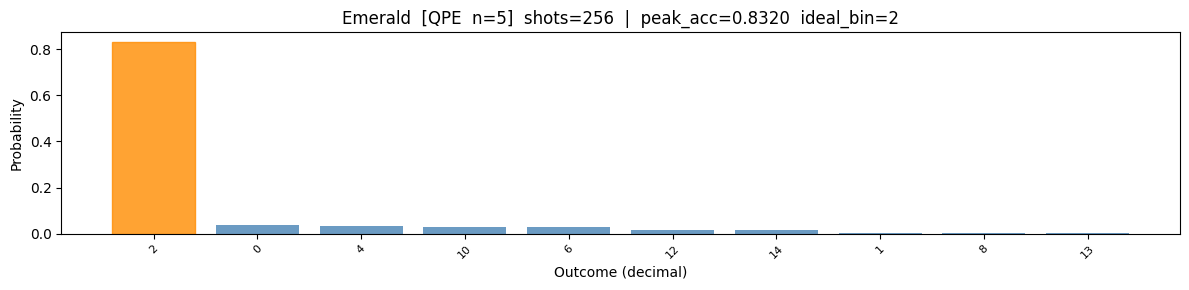


  [QPE  n=10]  shots=256  task=edee0c1d...
    QPE peak accuracy: 0.0156  (1.0 = all shots at ideal bin)
    Ideal bin        : 64  (binary 001000000)  →  φ ≈ 0.1250
  Queue+exec time : 11.3 s
  Wall time       : 12.8 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Emerald_qpe_n10.png


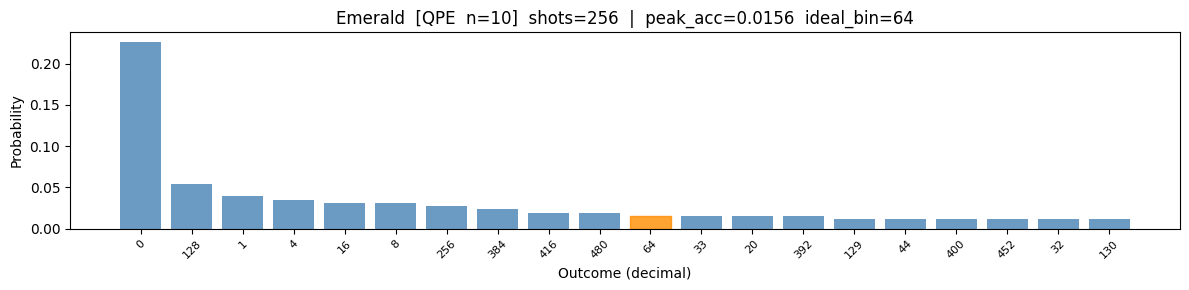


  [QPE  n=20]  shots=256  task=6fed6cea...
    QPE peak accuracy: 0.0000  (1.0 = all shots at ideal bin)
    Ideal bin        : 65536  (binary 0010000000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 22.1 s
  Wall time       : 24.3 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Emerald_qpe_n20.png


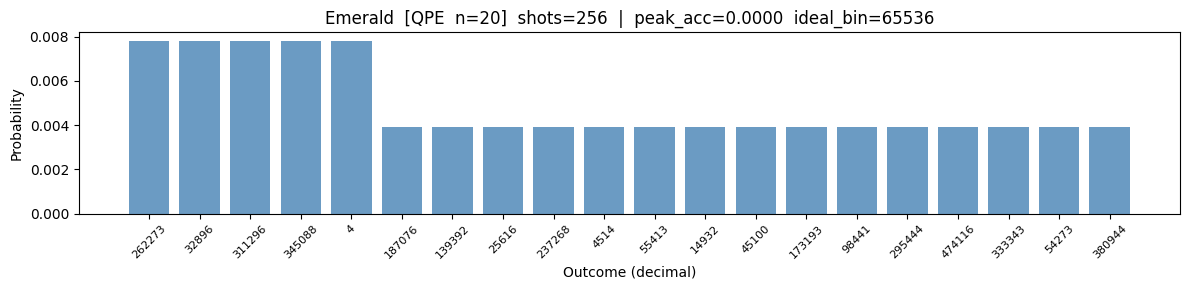


  [QPE  n=27]  shots=256  task=03511793...
    QPE peak accuracy: 0.0000  (1.0 = all shots at ideal bin)
    Ideal bin        : 8388608  (binary 00100000000000000000000000)  →  φ ≈ 0.1250
  Queue+exec time : 26.4 s
  Wall time       : 27.2 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Emerald_qpe_n27.png


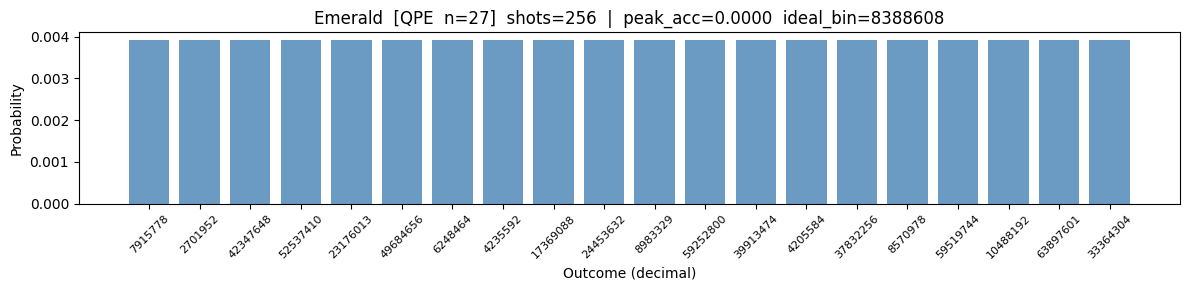

In [19]:
analyse_device('Emerald')

---
### 2-6: Rigetti Cepheus-1-108Q


  Device : Cepheus-1-108Q  (3 result(s), GHZ_DELTA=2)

  [GHZ  n=54]  shots=256  task=c42317a2...
    GHZ frac (δ=2) : 0.0000  (strict δ=0: 0.0000, 1.0 = perfect)
    Ideal shots      : 0/256
  Queue+exec time : 3.9 s
  Wall time       : 5.0 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/Cepheus_1_108Q_ghz_n54.png


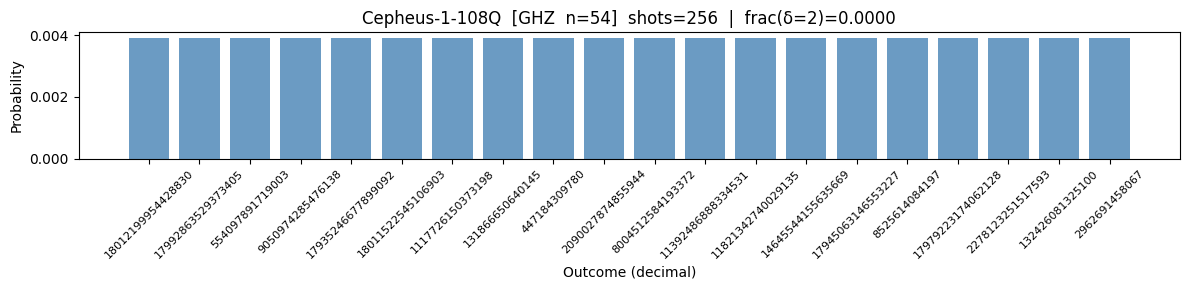


  [QPE  n=5]  shots=256  task=f31a6a65...
    QPE peak accuracy: 0.3555  (1.0 = all shots at ideal bin)
    Ideal bin        : 2  (binary 0010)  →  φ ≈ 0.1250
  Queue+exec time : 1467.9 s
  Wall time       : 1469.7 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Cepheus_1_108Q_qpe_n5.png


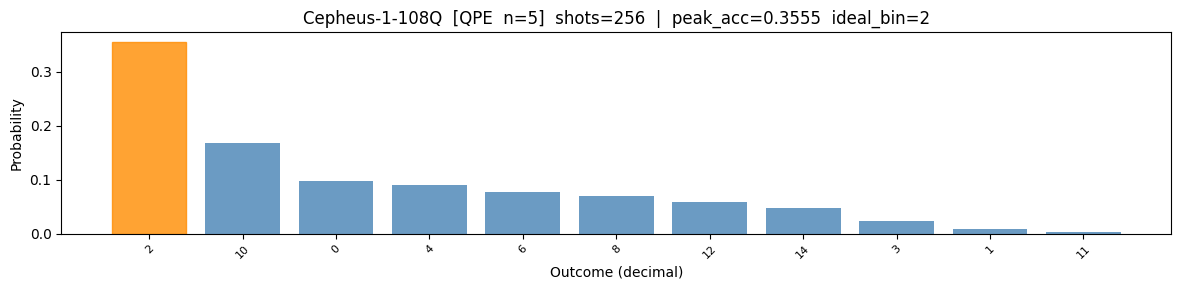


  [QPE  n=10]  shots=256  task=6f87f576...
    QPE peak accuracy: 0.0039  (1.0 = all shots at ideal bin)
    Ideal bin        : 64  (binary 001000000)  →  φ ≈ 0.1250
  Queue+exec time : 370.6 s
  Wall time       : 372.7 s
  QPU exec time   : not reported
    Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/Cepheus_1_108Q_qpe_n10.png


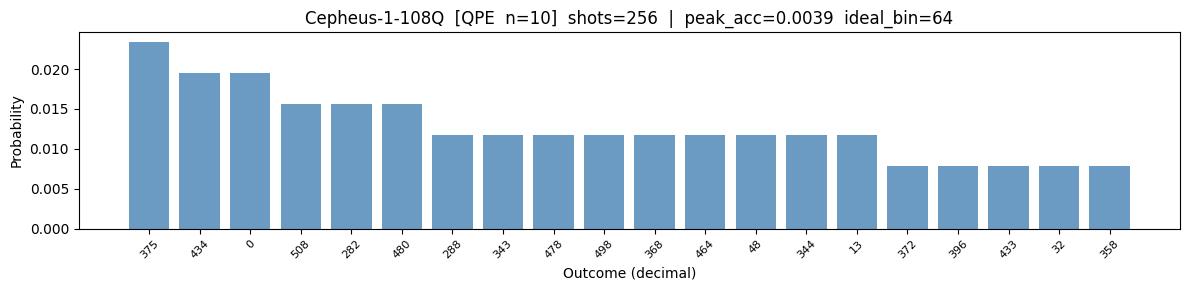

In [20]:
analyse_device('Cepheus-1-108Q')

---
## Section 3 – Cross-Device Comparison

Bar charts comparing each metric across all available devices.

- **QFT**: TVD from uniform (lower = better)
- **GHZ**: Ideal fraction (higher = better)
- **QPE**: Peak accuracy — fraction of shots at ideal bin (T gate, φ = 1/8, higher = better)

Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qft/qft_cross_device.png


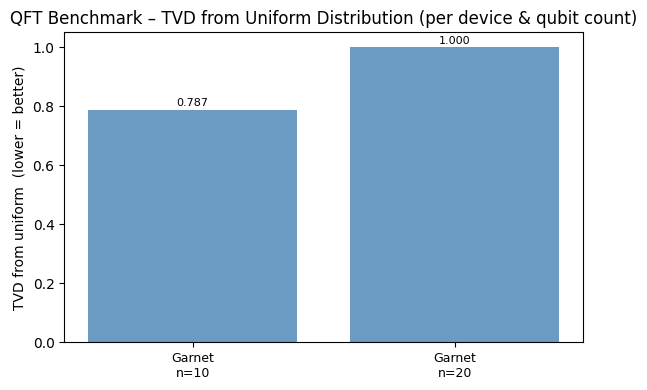

In [21]:
# ── QFT: TVD from uniform ─────────────────────────────────────────────────────
qft_results = load_results(circuit_type='QFT')

if not qft_results:
    print('No QFT results yet.')
else:
    labels = []
    tvds   = []
    for r in sorted(qft_results, key=lambda x: (x['device'], x['n_qubits'])):
        labels.append(f"{r['device']}\nn={r['n_qubits']}")
        tvds.append(tvd_from_uniform(r['counts']))

    fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.2), 4))
    bars = ax.bar(range(len(labels)), tvds, color='steelblue', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('TVD from uniform  (lower = better)')
    ax.set_title('QFT Benchmark – TVD from Uniform Distribution (per device & qubit count)')
    for bar, v in zip(bars, tvds):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    _path = os.path.join(PLOTS_DIR, 'qft', 'qft_cross_device.png')
    plt.savefig(_path, dpi=150)
    print(f'Saved → {_path}')
    plt.show()

Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/ghz/ghz_cross_device.png


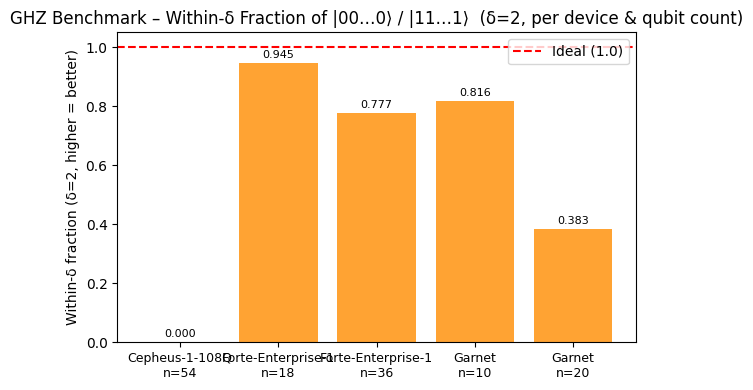

In [22]:
# ── GHZ: Within-δ fraction ────────────────────────────────────────────────────
ghz_results = load_results(circuit_type='GHZ')

if not ghz_results:
    print('No GHZ results yet.')
else:
    labels = []
    fracs  = []
    for r in sorted(ghz_results, key=lambda x: (x['device'], x['n_qubits'])):
        labels.append(f"{r['device']}\nn={r['n_qubits']}")
        fracs.append(ghz_within_delta_fraction(r['counts'], r['n_qubits'], delta=GHZ_DELTA))

    fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.2), 4))
    bars = ax.bar(range(len(labels)), fracs, color='darkorange', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='red', linestyle='--', label='Ideal (1.0)')
    ax.set_ylabel(f'Within-δ fraction (δ={GHZ_DELTA}, higher = better)')
    ax.set_title(f'GHZ Benchmark – Within-δ Fraction of |00…0⟩ / |11…1⟩  '
                 f'(δ={GHZ_DELTA}, per device & qubit count)')
    ax.legend()
    for bar, v in zip(bars, fracs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    _path = os.path.join(PLOTS_DIR, 'ghz', 'ghz_cross_device.png')
    plt.savefig(_path, dpi=150)
    print(f'Saved → {_path}')
    plt.show()

Saved → /Users/user/python/QUEN_QPUF/qpu_benchmark/plots/qpe_target1/qpe_cross_device.png


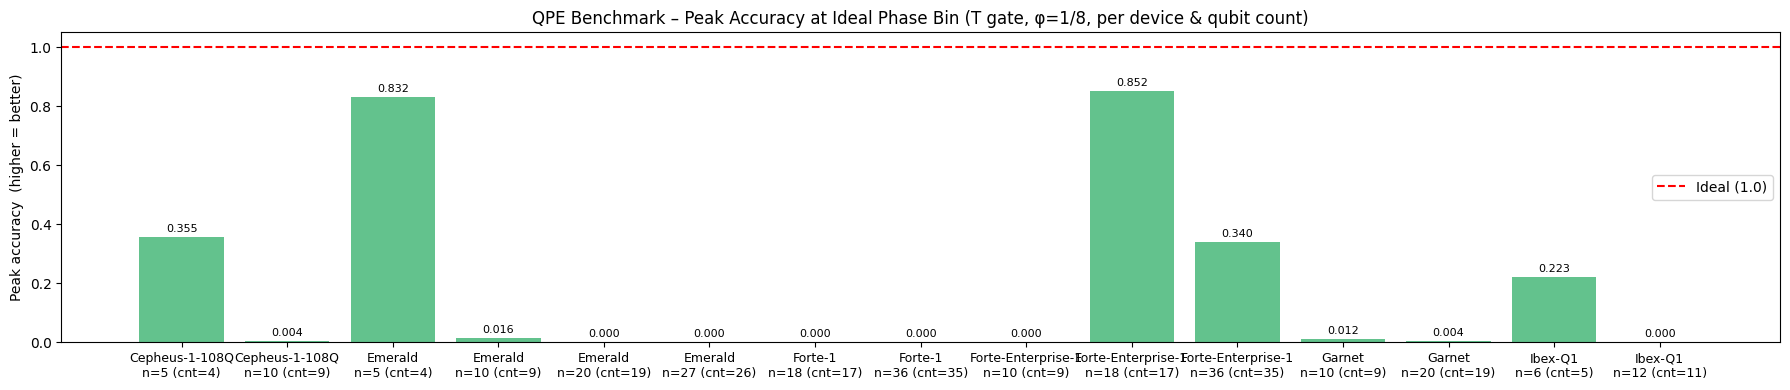

In [23]:
# ── QPE: Peak accuracy ─────────────────────────────────────────────────────────
qpe_results = load_results(circuit_type='QPE')

if not qpe_results:
    print('No QPE results yet.')
else:
    labels = []
    peaks  = []
    for r in sorted(qpe_results, key=lambda x: (x['device'], x['n_qubits'])):
        n_counting = r.get('n_counting', r['n_qubits'] - 1)
        counts_reg = {}
        for bitstr, cnt in r['counts'].items():
            key = bitstr[:n_counting]
            counts_reg[key] = counts_reg.get(key, 0) + cnt
        peak_frac, ideal_bin = qpe_peak_accuracy(counts_reg, n_counting)
        labels.append(f"{r['device']}\nn={r['n_qubits']} (cnt={n_counting})")
        peaks.append(peak_frac)

    fig, ax = plt.subplots(figsize=(max(6, len(labels) * 1.2), 4))
    bars = ax.bar(range(len(labels)), peaks, color='mediumseagreen', alpha=0.8)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylim(0, 1.05)
    ax.axhline(1.0, color='red', linestyle='--', label='Ideal (1.0)')
    ax.set_ylabel('Peak accuracy  (higher = better)')
    ax.set_title('QPE Benchmark – Peak Accuracy at Ideal Phase Bin (T gate, φ=1/8, per device & qubit count)')
    ax.legend()
    for bar, v in zip(bars, peaks):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    _path = os.path.join(PLOTS_DIR, 'qpe_target1', 'qpe_cross_device.png')
    plt.savefig(_path, dpi=150)
    print(f'Saved → {_path}')
    plt.show()

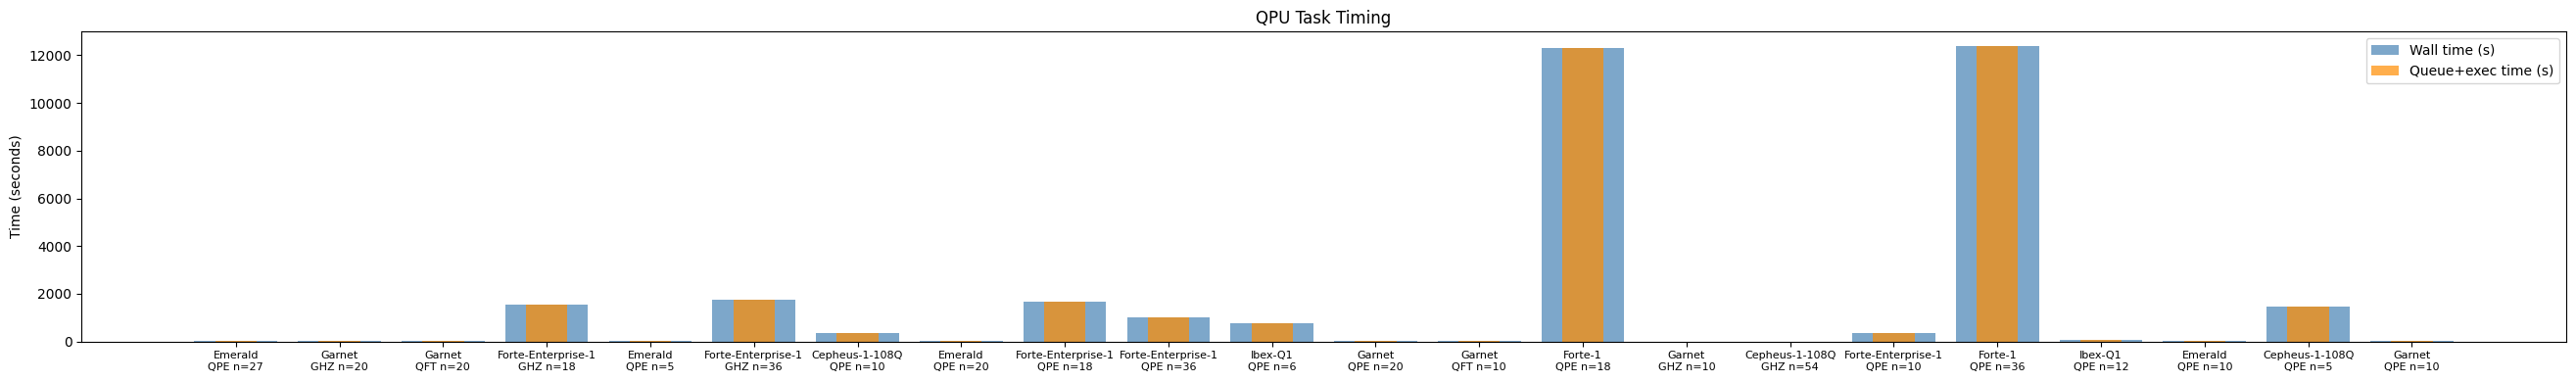

Timing summary:
  Label                                     Wall (s)    Queue (s)   QPU (s)
  --------------------------------------------------------------------------------
  Emerald QPE n=27                          27.2        26.4        N/A
  Garnet GHZ n=20                           7.9         7.6         N/A
  Garnet QFT n=20                           14.2        13.9        N/A
  Forte-Enterprise-1 GHZ n=18               1562.8      1561.9      N/A
  Emerald QPE n=5                           11.1        9.2         N/A
  Forte-Enterprise-1 GHZ n=36               1753.9      1753.7      N/A
  Cepheus-1-108Q QPE n=10                   372.7       370.6       N/A
  Emerald QPE n=20                          24.3        22.1        N/A
  Forte-Enterprise-1 QPE n=18               1660.9      1659.5      N/A
  Forte-Enterprise-1 QPE n=36               1016.8      1016.1      N/A
  Ibex-Q1 QPE n=6                           764.0       762.4       N/A
  Garnet QPE n=20                

In [24]:
# ── Timing comparison ─────────────────────────────────────────────────────────
if not all_results:
    print('No results to plot timing for.')
else:
    timing_data = []
    for r in all_results:
        wall  = r.get('wall_time_seconds')
        queue = r.get('queue_time_seconds')
        qpu   = r.get('qpu_time_seconds')
        if wall is not None or queue is not None:
            timing_data.append({
                'label':       f"{r['device']}\n{r['circuit_type']} n={r['n_qubits']}",
                'wall':        wall,
                'queue':       queue,
                'qpu':         qpu,
            })

    if not timing_data:
        print('Timing data not yet available in results.')
    else:
        fig, ax = plt.subplots(figsize=(max(8, len(timing_data) * 1.2), 4))
        x      = range(len(timing_data))
        labels = [d['label'] for d in timing_data]
        walls  = [d['wall']  or 0 for d in timing_data]
        queues = [d['queue'] or 0 for d in timing_data]

        ax.bar(x, walls,  label='Wall time (s)',       alpha=0.7, color='steelblue')
        ax.bar(x, queues, label='Queue+exec time (s)', alpha=0.7, color='darkorange', width=0.4)

        # Overlay QPU time if available
        qpu_times = [d['qpu'] for d in timing_data]
        if any(q is not None for q in qpu_times):
            qpu_y = [q or 0 for q in qpu_times]
            ax.scatter(x, qpu_y, color='red', zorder=5, label='QPU exec time (s)', s=60)

        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=8)
        ax.set_ylabel('Time (seconds)')
        ax.set_title('QPU Task Timing')
        ax.legend()
        plt.tight_layout()
        plt.show()

        print('Timing summary:')
        print(f'  {"Label":40s}  {"Wall (s)":10s}  {"Queue (s)":10s}  {"QPU (s)"}')
        print(f'  {"-"*80}')
        for d in timing_data:
            lbl   = d['label'].replace('\n', ' ')
            wall  = f"{d['wall']:.1f}"  if d['wall']  is not None else 'N/A'
            queue = f"{d['queue']:.1f}" if d['queue'] is not None else 'N/A'
            qpu   = f"{d['qpu']:.4f}"  if d['qpu']   is not None else 'N/A'
            print(f'  {lbl:40s}  {wall:10s}  {queue:10s}  {qpu}')